In [16]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle
from scipy.stats import percentileofscore
from statsmodels.stats.contingency_tables import mcnemar

from PIL import Image

import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as colors

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [17]:
ssplist = ["370"]

ssplistplot = ["hist","370"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1980,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1970,2025]
baselineera_obs = [1950,1980]

inputlength = 10
outputavgtime = 10
# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon
lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

device = 'mps'


data/MPI_annualmean_370_tos_1900-2100.pkl


In [18]:

imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

lenobs = experiment_era_obs[1]-experiment_era_obs[0]-outputavgtime-inputlength+1

In [19]:
landmask = np.isnan(np.nanmean(AllObs.alloutput,axis=0))

In [20]:
hindcastfilesin = sorted(glob.glob("../MPIhindcasts/data/MPIhindcast_summertime_tas_*.pkl"))

alldataALL = []

for ifile,filein in enumerate(hindcastfilesin[1:]):
    
    with open(filein,'rb') as f:
        indata = pickle.load(f)

    alldataALL.append(indata[0])

MPIforecastcut0 = experiment_era_obs[0]-1961
MPIforecastcut1 = experiment_era_obs[1]-2020

alldataALL= np.asarray(alldataALL)
if outputavgtime>5:
    alldatacut = alldataALL[(MPIforecastcut0+inputlength):MPIforecastcut1-outputavgtime]
elif outputavgtime==5:
    alldatacut = alldataALL[(MPIforecastcut0+inputlength):]
else:
    print('not able to do this lol')

leadtimebias = np.empty((alldatacut.shape[0],1,alldataALL.shape[2],alldataALL.shape[3],alldataALL.shape[4]))
leadtimebias[0] = np.mean(alldataALL[:MPIforecastcut0+inputlength],axis=(0,1),keepdims=True)

for itime in range(1,alldatacut.shape[0]):

    leadtimebias[itime] = np.mean(alldataALL[:MPIforecastcut0+inputlength+itime],axis=(0,1),keepdims=True)


#
alldata_corrected = alldatacut-leadtimebias
hindcast_summerclimo_anomish = np.mean(alldataALL[:30,:,0],axis=(0,1))-leadtimebias[:,:,[0]]

alldata_forecasts = alldatacut-leadtimebias-hindcast_summerclimo_anomish


In [21]:
def bb(forecast1,forecast2,verification,autocorr,nboots):

    nsamps = len(forecast1)
    nsampsgrab = int(np.round(nsamps/autocorr))

    fdiff = np.empty(nboots)
    # f2acc = np.empty(nboots)
    fbss = np.empty(nboots)
    # f2bs = np.empty(nboots)

    for iboot in range(nboots):
        sampsel = np.random.choice(nsamps-autocorr,nsampsgrab,replace=True)
        sampsel = (sampsel[:,np.newaxis]+np.arange(autocorr)).flatten()

        forecast1sel = forecast1[sampsel]
        forecast2sel = forecast2[sampsel]
        verifsel = verification[sampsel]

        fdiff[iboot] = np.mean(np.round(forecast1sel)==verifsel) - np.mean(np.round(forecast2sel)==verifsel)

        f1bs = helpers.brierscore(forecast1sel.squeeze(),verifsel.squeeze())
        f2bs = helpers.brierscore(forecast2sel.squeeze(),verifsel.squeeze())

        fbss[iboot] = 1-(f1bs/f2bs)

    return fdiff,fbss


In [31]:
nboots = 500
autocorr = 10

obsnull = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsaccuracy = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
hindcastaccuracy = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsaccuracy_climo = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obsprecision = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsprecision_climo = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
hindcastprecision = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obs_bs = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obs_bs_climo = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
hindcast_bs = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obsaccuracy_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obs_bs_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsclimo_bs_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsclimo_acc_bb = np.empty((nboots,len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

allobspredictions = np.empty((len(AllObs.output_lat),len(AllObs.output_lon),lenobs))+np.nan
allMPIpredictions = np.empty((len(AllObs.output_lat),len(AllObs.output_lon),lenobs))+np.nan
allrecordmags = np.empty((len(AllObs.output_lat),len(AllObs.output_lon),lenobs))+np.nan

mcnemarstat = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))
mcnemarpval = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))

lr_bs = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
lr_acc = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

lr_modelfilefront = "MPI_histrecord_"
# lr_modelfilefront = "MPI_recordtemp_"

for ilat,lat in enumerate(AllObs.output_lat):

    for ilon,lon in enumerate(AllObs.output_lon):

        metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed*.json"
        filelist = glob.glob(metricsout)

        if (len(filelist)!=0) & (lat>-55):
            # print('models exist, proceeding')

            bestseeds = helpers.get_best_files(filelist,n_best)
            # obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)
            obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)

            obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
            obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
            obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
            obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)
            
            obsinput_climo = AllObs.cutinput
            obsinput_meaninput = np.mean(obsinput_climo,axis=0,keepdims=True)
            obsinput_meaninput_anom = torch.tensor(obsinput_meaninput-np.mean(obsinput_meaninput,axis=1,keepdims=True),dtype=torch.float32)
            obsinput_sstclimo = obsinput_meaninput_anom*torch.ones(obsinput_t.size())
            # obsinput_sstclimo = torch.mean(obsinput_t,axis=0,keepdims=True)*torch.ones(obsinput_t.size())

            # print(bestseeds)
            obsnull[ilat,ilon] = np.max([np.mean(obsoutput),1-np.mean(obsoutput)])

            obspredall = np.empty((3,len(obsinputgmt)))
            obspredclimo = np.empty((3,len(obsinputgmt)))

            for iseed,seed in enumerate(bestseeds):
                # load the model

                loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed_"+str(seed)+".pt"
                cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
                cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
                cnn.to(device)

                with torch.no_grad():
                    cnn.eval()
                    obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()
                    obspred_climo = cnn(obsinput_sstclimo.to(device), obsinputvectors_t.to(device)).cpu().numpy()

                obspredall[iseed] = obspred[:,1]
                obspredclimo[iseed] = obspred_climo[:,1]

            obspredavg = np.mean(obspredall,axis=0)
            obspredclass = np.round(obspredavg)

            obspredavg_climo = np.mean(obspredclimo,axis=0)
            obspredclass_climo = np.round(obspredavg_climo)

            obsaccuracy[ilat,ilon] = np.mean(obsoutput==obspredclass)            
            obsaccuracy_climo[ilat,ilon] = np.mean(obsoutput==obspredclass_climo)

            obsprecision[ilat,ilon] = helpers.precision(obspredclass,obsoutput,1)
            obsprecision_climo[ilat,ilon] = helpers.precision(obspredclass_climo,obsoutput,1)

            obs_bs[ilat,ilon] = helpers.brierscore(obspredavg.squeeze(),obsoutput.squeeze())
            obs_bs_climo[ilat,ilon] = helpers.brierscore(obspredavg_climo.squeeze(),obsoutput.squeeze())

            if lat<0:
                MPIhindcast_maxdistribution = np.max(np.sort(alldata_forecasts[:,:,1:outputavgtime+1,ilat,ilon],axis=1),axis=2)
                lentime = len(obsinputpriorrecord)

                MPIconfs = np.empty(lentime)
                for itime in range(lentime):
                    MPIconfs[itime] = 100-percentileofscore(MPIhindcast_maxdistribution[itime].squeeze(),obsinputpriorrecord[itime].squeeze())
            else:
                MPIhindcast_maxdistribution = np.max(np.sort(alldata_forecasts[:,:,:outputavgtime,ilat,ilon],axis=1),axis=2)
                lentime = len(obsinputpriorrecord)

                MPIconfs = np.empty(lentime)
                for itime in range(lentime):
                    MPIconfs[itime] = 100-percentileofscore(MPIhindcast_maxdistribution[itime].squeeze(),obsinputpriorrecord[itime].squeeze())

            MPIconfs = MPIconfs/100
            MPIpredclass = np.round(MPIconfs)


            hindcastaccuracy[ilat,ilon] = np.mean(obsoutput==MPIpredclass)
            hindcast_bs[ilat,ilon] = helpers.brierscore(MPIconfs.squeeze(),obsoutput.squeeze())
            hindcastprecision[ilat,ilon] = helpers.precision(MPIpredclass,obsoutput,1)

            lrmodelload = "lr_models/"+lr_modelfilefront + "LogisticRegression_avgtime_"+str(outputavgtime)+"_lat_"+str(lat)+"_lon_"+str(lon)+".joblib"
            lrmodel = joblib.load(lrmodelload)

            lrpred = lrmodel.predict_proba(obsinputvectors_t[:,[0]].numpy())[:,1]
            lr_bs[ilat,ilon] = helpers.brierscore(lrpred,obsoutput.squeeze())
            lr_acc[ilat,ilon] = np.mean(np.round(lrpred)==obsoutput)

            obsaccuracy_bb[:,ilat,ilon],obs_bs_bb[:,ilat,ilon] = bb(
                obspredavg,MPIconfs,obsoutput,autocorr,nboots)
            
            obsclimo_acc_bb[:,ilat,ilon],obsclimo_bs_bb[:,ilat,ilon] = bb(
                obspredavg,obspredavg_climo,obsoutput,autocorr,nboots)
            
            correct_A = (obsoutput == obspredclass)
            correct_B = (obsoutput == MPIpredclass)

            # Build 2x2 table
            table = [[sum(correct_A & correct_B), sum(correct_A & ~correct_B)],
                    [sum(~correct_A & correct_B), sum(~correct_A & ~correct_B)]]


            # Run McNemar's test
            result = mcnemar(table, exact=True)  # exact=True for small samples
            mcnemarstat[ilat,ilon] = result.statistic
            mcnemarpval[ilat,ilon] = result.pvalue

            if lat<0:
                allobspredictions[ilat,ilon] = obspredavg
                allMPIpredictions[ilat,ilon] = MPIconfs
                # allrecordmags[ilat,ilon] = AllObs.recordmags[inputlength:-1*(outputavgtime)]
            else:
                allobspredictions[ilat,ilon] = obspredavg[1:]
                allMPIpredictions[ilat,ilon] = MPIconfs[1:]
                # allrecordmags[ilat,ilon] = AllObs.recordmags[inputlength:-1*(outputavgtime)]
        # else:
            # print('no model for '+ str(lat) + ' ' + str(lon))



/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/egor650/.local/share/mamba/envs/ml-env/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpic

Text(0.5, 0, 'Brier Skill Score')

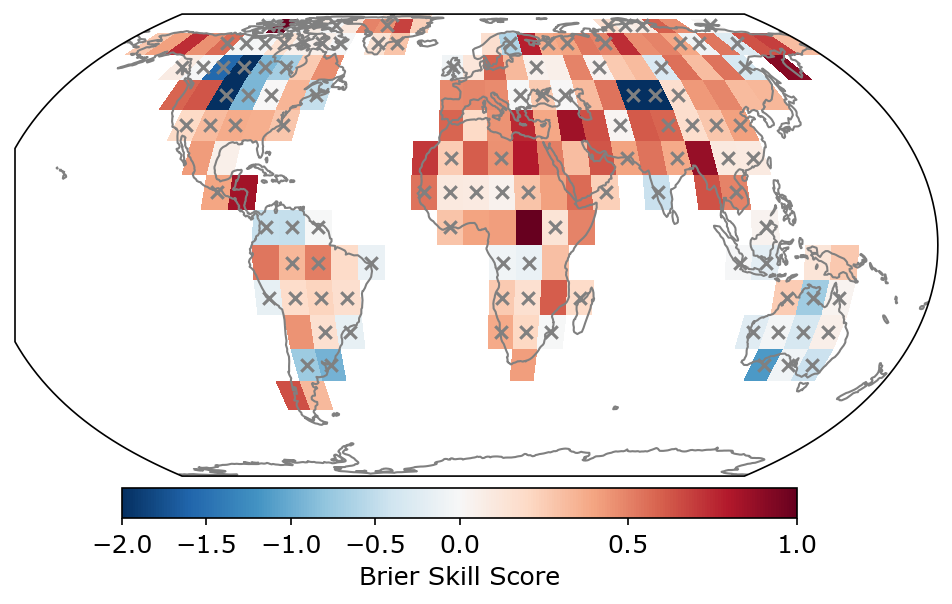

In [33]:
lonsig = lonmesh[0>=np.percentile(obs_bs_bb,10,axis=0)]
latsig = latmesh[0>=np.percentile(obs_bs_bb,10,axis=0)]

norm = colors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=1)

plt.figure(figsize=(9,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,1-(obs_bs/hindcast_bs),norm=norm,cmap="RdBu_r",transform=ccrs.PlateCarree())
ax.scatter(lonsig,latsig,marker='x',transform=ccrs.PlateCarree(),color='grey')
ax.coastlines(color='grey')

cax = plt.axes((0.25,0.04,0.5,0.05))
cbar = plt.colorbar(c1,cax,orientation='horizontal')
cbar.ax.set_xlabel("Brier Skill Score")

Text(0.5, 0, 'Brier Score')

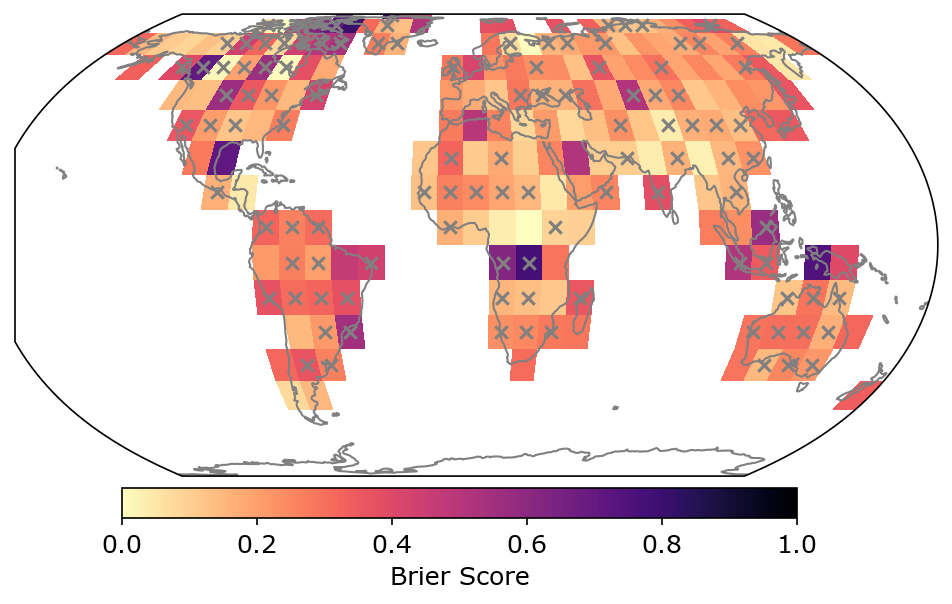

In [34]:
lonsig = lonmesh[0>=np.percentile(obs_bs_bb,10,axis=0)]
latsig = latmesh[0>=np.percentile(obs_bs_bb,10,axis=0)]

norm = colors.TwoSlopeNorm(vmin=-2, vcenter=0, vmax=1)

plt.figure(figsize=(9,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,obs_bs,vmin=0,vmax=1,cmap='magma_r',transform=ccrs.PlateCarree())
ax.scatter(lonsig,latsig,marker='x',transform=ccrs.PlateCarree(),color='grey')
ax.coastlines(color='grey')

cax = plt.axes((0.25,0.04,0.5,0.05))
cbar = plt.colorbar(c1,cax,orientation='horizontal')
cbar.ax.set_xlabel("Brier Score")

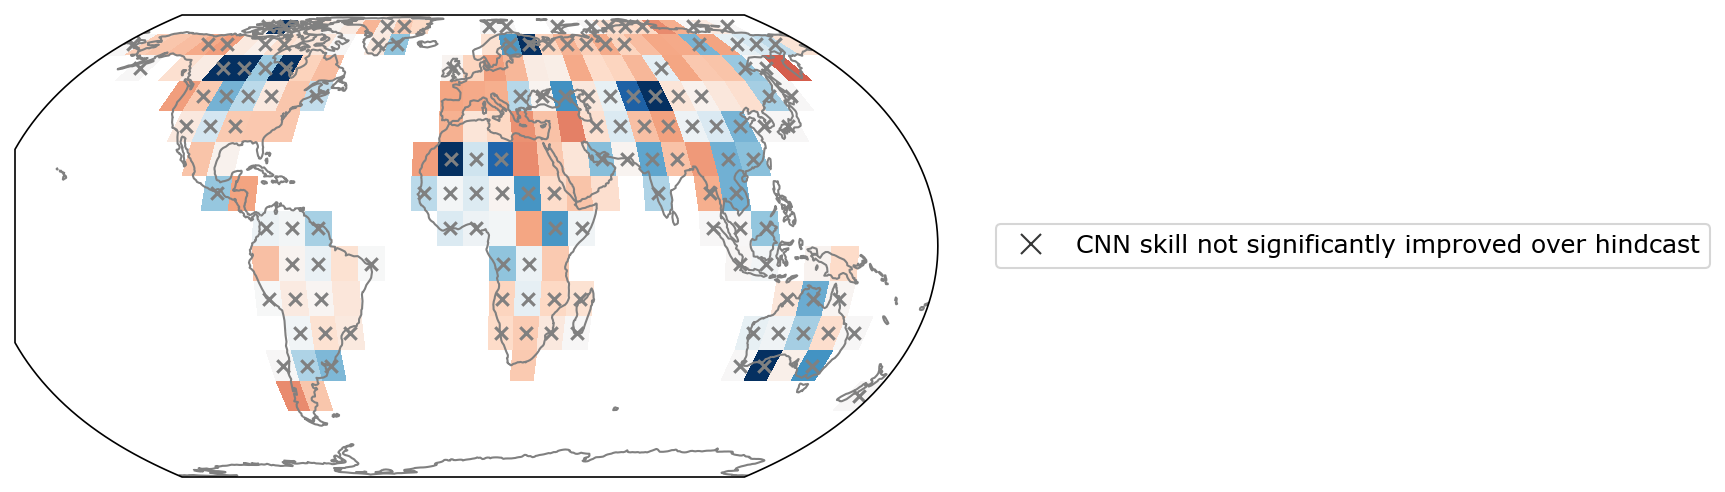

In [35]:
lonsig_climo = lonmesh[0>=np.percentile(obsclimo_bs_bb,10,axis=0)]
latsig_climo = latmesh[0>=np.percentile(obsclimo_bs_bb,10,axis=0)]

plt.figure(figsize=(9,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,1-(obs_bs/obs_bs_climo),vmin=-1.5,vmax=1.5,cmap="RdBu_r",transform=ccrs.PlateCarree())
ax.scatter(lonsig_climo,latsig_climo,marker='x',transform=ccrs.PlateCarree(),color='grey')
ax.coastlines(color='grey')

dot_handle = mlines.Line2D([], [], color='xkcd:dark gray', marker='x', linestyle='None', 
                           markersize=10, label='CNN skill not significantly improved over hindcast')

ax.legend(
    handles=[dot_handle, ], 
    loc='center left',             # Anchor the left edge of the legend box
    bbox_to_anchor=(1.05, 0.5),    # Position it just past the right edge (1.0) of the map
    frameon=True
)

# cax = plt.axes((0.96,0.1,0.02,0.8))
# cbar = plt.colorbar(c1,cax)
# cbar.ax.set_ylabel("Brier Skill Score")

Text(0.5, 0, 'Brier Skill Score')

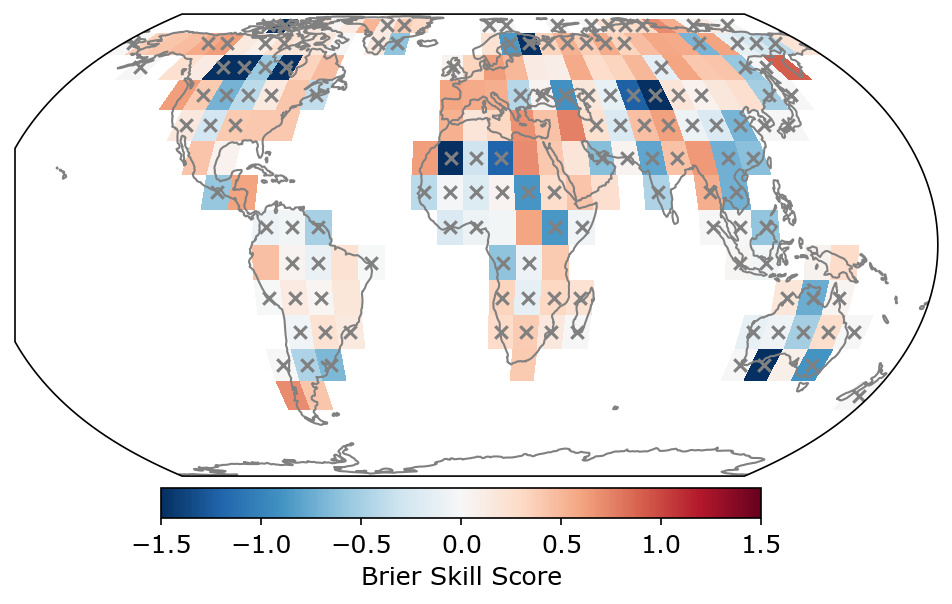

In [36]:
lonsiglr_bs = lonmesh[0>=np.percentile(obsclimo_bs_bb,10,axis=0)]
latsiglr_bs = latmesh[0>=np.percentile(obsclimo_bs_bb,10,axis=0)]

lonsiglr_acc = lonmesh[0>=np.percentile(obsclimo_acc_bb,10,axis=0)]
latsiglr_acc = latmesh[0>=np.percentile(obsclimo_acc_bb,10,axis=0)]

plt.figure(figsize=(8,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,1-(obs_bs/obs_bs_climo),vmin=-1.5,vmax=1.5,cmap="RdBu_r",transform=ccrs.PlateCarree())
ax.scatter(lonsiglr_bs,latsiglr_bs,marker='x',transform=ccrs.PlateCarree(),color='grey')
ax.coastlines(color='grey')


cax = plt.axes((0.25,0.04,0.5,0.05))
cbar = plt.colorbar(c1,cax,orientation='horizontal')
cbar.ax.set_xlabel("Brier Skill Score")

Text(0.5, 0, 'accuracy difference')

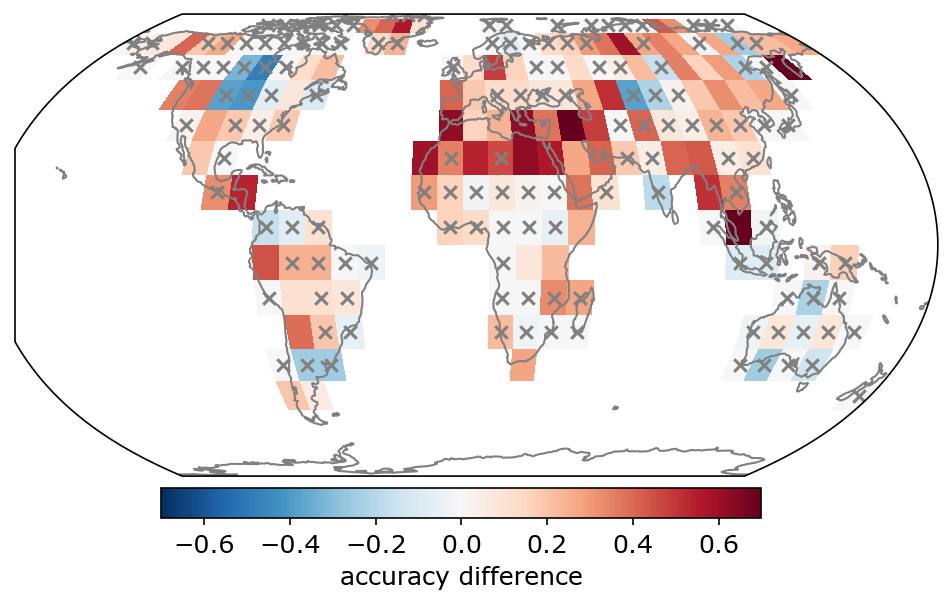

In [37]:
lonsigMPI_acc = lonmesh[0>=np.percentile(obsaccuracy_bb,10,axis=0)]
latsigMPI_acc = latmesh[0>=np.percentile(obsaccuracy_bb,10,axis=0)]

plt.figure(figsize=(8,4))

ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,obsaccuracy-hindcastaccuracy,vmin=-0.7,vmax=0.7,cmap="RdBu_r",transform=ccrs.PlateCarree())
ax.scatter(lonsigMPI_acc,latsigMPI_acc,marker='x',transform=ccrs.PlateCarree(),color='grey')
ax.coastlines(color='grey')

cax = plt.axes((0.25,0.04,0.5,0.05))
cbar = plt.colorbar(c1,cax,orientation='horizontal')
cbar.ax.set_xlabel("accuracy difference")

In [28]:
# plt.figure(figsize=(8,4))

# ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
# c1=ax.pcolormesh(lonvec+5,latvec+5,obsprecision-obsprecision_climo,vmin=-0.1,vmax=0.1,cmap="RdBu_r",transform=ccrs.PlateCarree())
# # ax.scatter(lonsigMPI_acc,latsigMPI_acc,marker='x',transform=ccrs.PlateCarree(),color='grey')
# ax.coastlines(color='grey')

# cax = plt.axes((0.25,0.04,0.5,0.05))
# cbar = plt.colorbar(c1,cax,orientation='horizontal')
# cbar.ax.set_xlabel("precision")

In [29]:
x = np.arange(0,1,0.02)
y = 1-(x/0.9)

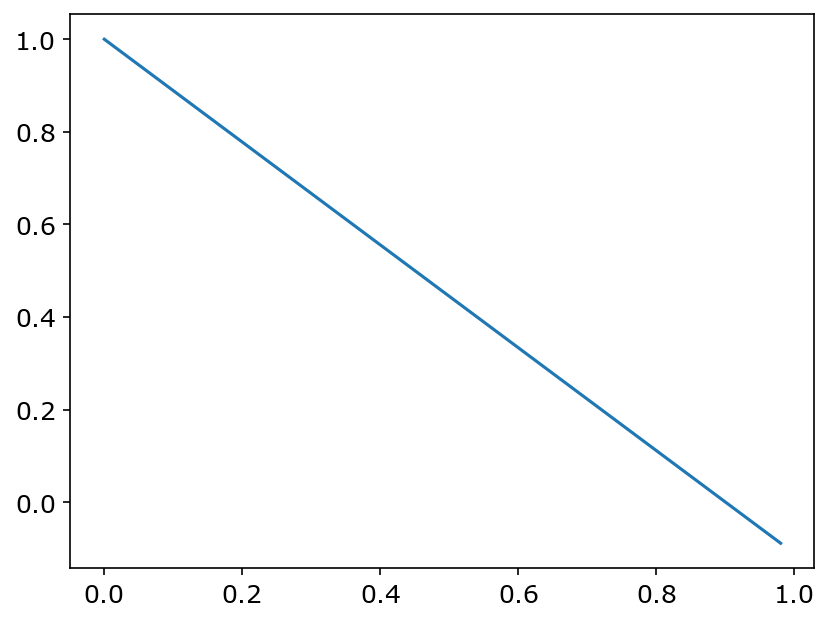

In [30]:
plt.plot(x,y)